In [10]:
# =============================================================
# 1 - Imports and environment setup
#
# What this does:
#   - loads all required libraries
#   - sets espeak-ng paths so phonemizer finds it on Windows
#   - verifies espeak works before running anything else
#
# Libraries used:
#   - torch / transformers : Wav2Vec2 neural network
#   - librosa              : audio loading and resampling
#   - phonemizer           : Python wrapper around espeak-ng
#   - Bio.Align            : Needleman-Wunsch sequence alignment
#   - sklearn              : precision, recall, F1 metrics
#   - pandas / numpy       : data manipulation
# =============================================================

import os
import json
import subprocess
import unicodedata
import warnings

import numpy as np
import pandas as pd
import torch
import librosa

from transformers import (
    AutoModelForCTC,
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
)
from huggingface_hub import snapshot_download
from phonemizer import phonemize
from Bio import Align
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# ── espeak-ng paths (Windows) ─────────────────────────────────
# phonemizer needs to know exactly where espeak-ng is installed
# because Windows does not always expose it automatically
ESPEAK_EXE = r"C:\Program Files\eSpeak NG\espeak-ng.exe"
ESPEAK_DLL = r"C:\Program Files\eSpeak NG\libespeak-ng.dll"

os.environ["PHONEMIZER_ESPEAK_PATH"]    = ESPEAK_EXE
os.environ["PHONEMIZER_ESPEAK_LIBRARY"] = ESPEAK_DLL

# ── Paths ─────────────────────────────────────────────────────
MODEL_CACHE_DIR = r"C:\Users\Sarah\back2speak\model_cache"
AUDIO_DIR       = r"C:\Users\Sarah\datathon_back2speak\Donnees\ch\Fichiers audio cleaned"
AUDIO_DB_PATH   = r"C:\Users\Sarah\audio_db.csv"
ITEMS_PATH      = r"C:\Users\Sarah\items.csv"

os.makedirs(MODEL_CACHE_DIR, exist_ok=True)

# ── Quick sanity check ────────────────────────────────────────
print("Checking espeak-ng...")
result = subprocess.run(
    [ESPEAK_EXE, "--ipa", "-v", "fr", "chapeau"],
    capture_output=True, text=True, encoding="utf-8"
)
print(f"  espeak output for 'chapeau': {result.stdout.strip()}")
print(f"  expected: ʃapo")
print()
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name:      {torch.cuda.get_device_name(0)}")
print("Environment ready.")

Checking espeak-ng...
  espeak output for 'chapeau': ʃapˈo
  expected: ʃapo

GPU available: True
GPU name:      NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU
Environment ready.


In [ ]:
# =============================================================
# 2 - Load the French Wav2Vec2 phoneme model
#
# Model: Cnam-LMSSC/wav2vec2-french-phonemizer
#   - fine-tuned on Common Voice v13 French
#   - outputs IPA phonemes directly (not words)
#   - uses CTC decoding to collapse repeated phonemes
#
# Why we load it manually instead of from_pretrained():
#   The model's config files contain absolute paths from the
#   researcher's local machine (/home/zinc/...) which break
#   loading on any other machine. We fix those files before
#   loading.
#
# First run: downloads ~400MB to MODEL_CACHE_DIR
# Subsequent runs: loads from local cache instantly
# =============================================================

MODEL_ID = "Cnam-LMSSC/wav2vec2-french-phonemizer"
# MODEL_ID = "facebook/wav2vec-lv-60-espeak-cv-ft"

print(f"Downloading model files to: {MODEL_CACHE_DIR}")
print("First run takes ~2 minutes, then instant...")

snapshot_dir = snapshot_download(
    repo_id=MODEL_ID,
    local_dir=MODEL_CACHE_DIR,
    local_dir_use_symlinks=False   # required on Windows (no symlink privilege)
)
print(f"Model files at: {snapshot_dir}")
print()

# ── Fix broken config files ───────────────────────────────────
# Fix 1: tokenizer_config.json contains absolute paths
tok_path = os.path.join(snapshot_dir, "tokenizer_config.json")
with open(tok_path, "r", encoding="utf-8") as f:
    tok_cfg = json.load(f)
tok_cfg.pop("special_tokens_map_file", None)
tok_cfg.pop("name_or_path",            None)
tok_cfg.pop("tokenizer_file",          None)
tok_cfg["extra_special_tokens"] = {}
with open(tok_path, "w", encoding="utf-8") as f:
    json.dump(tok_cfg, f, ensure_ascii=False, indent=2)

# Fix 2: special_tokens_map.json stores tokens as dicts instead of strings
spm_path = os.path.join(snapshot_dir, "special_tokens_map.json")
with open(spm_path, "r", encoding="utf-8") as f:
    spm = json.load(f)
if "additional_special_tokens" in spm:
    spm["additional_special_tokens"] = [
        t["content"] if isinstance(t, dict) else t
        for t in spm["additional_special_tokens"]
    ]
with open(spm_path, "w", encoding="utf-8") as f:
    json.dump(spm, f, ensure_ascii=False, indent=2)

print("Config files fixed.")

# ── Load tokenizer ────────────────────────────────────────────
# We load directly from vocab.json to bypass all config files
# The tokenizer converts model output IDs back to IPA symbols
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file=os.path.join(snapshot_dir, "vocab.json"),
    unk_token="[UNK]", pad_token="[PAD]",
    bos_token="<s>",   eos_token="</s>",
    word_delimiter_token="|", do_lower_case=False,
)

# ── Load feature extractor ────────────────────────────────────
# Normalizes the raw audio waveform before feeding to the model
# (zero mean, unit variance - required by Wav2Vec2)
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1, sampling_rate=16000,
    padding_value=0.0, do_normalize=True,
    return_attention_mask=False,
)

# ── Build processor ───────────────────────────────────────────
# Combines feature_extractor + tokenizer into one object
processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor,
    tokenizer=tokenizer,
)

# ── Load neural network weights ───────────────────────────────
# 94M parameter Wav2Vec2 model with CTC head
# Moved to GPU for ~10x faster inference
model  = AutoModelForCTC.from_pretrained(snapshot_dir)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

print()
print("=" * 50)
print(f"Model loaded on: {device}")
print(f"Parameters:      {sum(p.numel() for p in model.parameters()):,}")
vocab = tokenizer.get_vocab()
print(f"Vocabulary size: {len(vocab)} IPA phoneme tokens")
print()
print("Key French phonemes confirmed in vocabulary:")
for ph in ['ʃ', 's', 'k', 'ʒ', 'a', 'o', 'i', 'ʁ', 'ɛ']:
    print(f"  [{ph}] -> token ID {vocab.get(ph, 'MISSING')}")
print("=" * 50)

First run takes ~2 minutes, then instant...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/309 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

Model files at: C:\Users\Sarah\back2speak\model_cache

Config files fixed.

Model loaded on: cuda
Parameters:      94,418,621
Vocabulary size: 61 IPA phoneme tokens

Key French phonemes confirmed in vocabulary:
  [ʃ] -> token ID 46
  [s] -> token ID 17
  [k] -> token ID 10
  [ʒ] -> token ID 50
  [a] -> token ID 2
  [o] -> token ID 14
  [i] -> token ID 8
  [ʁ] -> token ID 45
  [ɛ] -> token ID 35


In [3]:
# =============================================================
# 3 - Load and merge the two CSV files
#
# CSV 1 — audio_db.csv (407 rows):
#   audio_id, speaker, age, sexe, position, type_item, decision
#   'decision' is the ground truth label:
#     'correct' / 'substitution_ch_vers_s' / 'distorsion' / 'indeterminé'
#
# CSV 2 — items.csv (31 rows):
#   item_id, mot/stimulus, type, position_du_/ʃ/,
#   Nombre de phonèmes, voyelle_précédente, voyelle_suivante
#
# Merge key:
#   audio filename 'P02_S02_W_F01.wav' -> item_id 'W_F01'
#   We extract the item_id from the filename and join on it
#
# Result: one merged dataframe with all metadata per audio file
# =============================================================

df_audio = pd.read_csv(r"C:\Users\Sarah\audio_db.csv")
df_items = pd.read_csv(r"C:\Users\Sarah\items.csv")

df_audio["decision"] = df_audio["decision"].str.strip()

# Clean item IDs in items CSV — remove leading bullets and dashes
df_items["item_id_clean"] = (
    df_items["item_id"]
    .astype(str).str.strip()
    .str.lstrip("•–- ").str.rstrip("–- ").str.strip()
)

def extract_item_id(audio_id):
    """
    Extract item_id from audio filename.
    'P02_S02_W_F01.wav' -> 'W_F01'
    'P02_S02_SYL01.wav' -> 'SYL01'
    'P02_S02_P04.wav'   -> 'P04'
    """
    parts = str(audio_id).replace(".wav", "").strip().split("_")
    return "_".join(parts[2:]) if len(parts) >= 3 else None

df_audio["item_id_extracted"] = df_audio["audio_id"].apply(extract_item_id)

# Merge audio metadata with item metadata
df = df_audio.merge(
    df_items,
    left_on="item_id_extracted",
    right_on="item_id_clean",
    how="left"
)

# Add full audio path and existence flag
df["audio_path"]  = df["audio_id"].apply(
    lambda x: os.path.join(AUDIO_DIR, x)
)
df["file_exists"] = df["audio_path"].apply(os.path.exists)

print(f"Audio DB rows:           {len(df_audio)}")
print(f"Items CSV rows:          {len(df_items)}")
print(f"Merged rows:             {len(df)}")
print(f"Files found on disk:     {df['file_exists'].sum()}")
print(f"Files missing on disk:   {(~df['file_exists']).sum()}")
print(f"Rows with target word:   {df['mot / stimulus'].notna().sum()}")
print()
print("Label distribution:")
print(df["decision"].value_counts().to_string())

Audio DB rows:           455
Items CSV rows:          31
Merged rows:             455
Files found on disk:     369
Files missing on disk:   86
Rows with target word:   433

Label distribution:
decision
correct                   406
distorsion                 31
substitution_ch_vers_s     17
indeterminé                 1


In [ ]:
# =============================================================
# CELL 3b — ʃ-specific confidence score
#
# Instead of averaging confidence over all phonemes,
# we look specifically at the frames where ʃ is expected
# and extract the probability distribution at that moment.
#
# This tells us:
#   - how confident the model is that [ʃ] was produced
#   - how confident it is that [s] was produced instead
#   - what other phonemes it considered
#
# This is much more clinically useful than a global score.
# =============================================================

def get_sh_confidence(audio_path, reference_ipa):
    """
    For a given audio file, find the frames where ʃ is expected
    and return the probability the model assigned to each phoneme
    at that position.

    How it works:
      1. Run Wav2Vec2 -> logits shape (1, T, 61)
      2. Apply softmax -> probabilities at each frame
      3. Use CTC alignment to find which frames correspond to ʃ
      4. At those frames, extract prob(ʃ), prob(s), prob(k), prob(ʒ)
      5. Average across all ʃ frames if there are multiple

    Input:
        audio_path    : path to WAV file
        reference_ipa : reference IPA string e.g. 'flɛʃ'

    Output:
        dict with keys:
            prob_sh       : probability the model assigned to [ʃ]  (0-1)
            prob_s        : probability the model assigned to [s]
            prob_top      : probability of the actual top phoneme
            top_phoneme   : which phoneme got the highest score
            confidence_sh : label — HIGH / MEDIUM / LOW
            all_probs     : full distribution over all 61 phonemes
                            sorted by probability (top 5)
    """
    try:
        waveform, _ = librosa.load(audio_path, sr=16000, mono=True)
        inputs = processor(
            waveform, sampling_rate=16000,
            return_tensors="pt", padding=True
        )

        with torch.no_grad():
            logits = model(inputs.input_values.to(device)).logits

        # Shape: (1, T, 61) -> (T, 61) after squeeze
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu()

        # Get predicted phoneme at each frame
        predicted_ids = torch.argmax(probs, dim=-1)  # shape: (T,)

        # Get token IDs for the phonemes we care about
        vocab    = processor.tokenizer.get_vocab()
        sh_id    = vocab.get("ʃ", -1)
        s_id     = vocab.get("s", -1)
        k_id     = vocab.get("k", -1)
        zh_id    = vocab.get("ʒ", -1)
        pad_id   = processor.tokenizer.pad_token_id

        # ── Find frames where model predicted ʃ or s ──────────
        # We look for frames where the model was choosing between
        # ʃ and s — these are the clinically relevant frames
        # Strategy: find non-blank frames and look for where
        # ʃ or s has significant probability (> 0.1)

        # First decode to get the produced phoneme string
        phonemes = processor.batch_decode(
            predicted_ids.unsqueeze(0)
        )[0].strip()

        # Find frames where ʃ probability is highest among
        # the target phonemes (ʃ, s, k, ʒ)
        # These are the frames "about" the CH sound
        target_ids = [sh_id, s_id, k_id, zh_id]
        target_ids = [i for i in target_ids if i >= 0]

        # For each frame, sum of probabilities of target phonemes
        target_probs_sum = probs[:, target_ids].sum(dim=1)  # shape (T,)

        # Find frames where model is "thinking about" CH-related phonemes
        # i.e. where at least 30% probability is on ʃ/s/k/ʒ
        sh_frames = (target_probs_sum > 0.3).nonzero(as_tuple=True)[0]

        # Also exclude blank/pad frames
        non_blank = (predicted_ids != pad_id)
        sh_frames_clean = [
            f.item() for f in sh_frames
            if non_blank[f]
        ]

        if not sh_frames_clean:
            # Fallback: use the frame with highest ʃ probability
            sh_frame_best = probs[:, sh_id].argmax().item()
            sh_frames_clean = [sh_frame_best]

        # Average probabilities across the relevant frames
        frame_probs = probs[sh_frames_clean]  # shape (n_frames, 61)
        avg_probs   = frame_probs.mean(dim=0) # shape (61,)

        prob_sh  = avg_probs[sh_id].item()  if sh_id  >= 0 else 0.0
        prob_s   = avg_probs[s_id].item()   if s_id   >= 0 else 0.0
        prob_k   = avg_probs[k_id].item()   if k_id   >= 0 else 0.0
        prob_zh  = avg_probs[zh_id].item()  if zh_id  >= 0 else 0.0

        # Top phoneme and its probability
        top_id      = avg_probs.argmax().item()
        prob_top    = avg_probs[top_id].item()

        # Decode top phoneme id to IPA character
        id_to_token = {v: k for k, v in vocab.items()}
        top_phoneme = id_to_token.get(top_id, "?")

        # Top 5 phonemes with their probabilities
        top5_ids    = avg_probs.topk(5).indices.tolist()
        top5_probs  = avg_probs.topk(5).values.tolist()
        top5 = [
            (id_to_token.get(i, "?"), round(p * 100, 1))
            for i, p in zip(top5_ids, top5_probs)
        ]

        # Confidence label specifically for ʃ
        if prob_sh >= 0.70:
            confidence_sh = "HIGH"
        elif prob_sh >= 0.40:
            confidence_sh = "MEDIUM"
        else:
            confidence_sh = "LOW"

        return {
            "phonemes":     phonemes,
            "prob_sh":      round(prob_sh  * 100, 1),
            "prob_s":       round(prob_s   * 100, 1),
            "prob_k":       round(prob_k   * 100, 1),
            "prob_zh":      round(prob_zh  * 100, 1),
            "top_phoneme":  top_phoneme,
            "prob_top":     round(prob_top * 100, 1),
            "confidence_sh": confidence_sh,
            "n_sh_frames":  len(sh_frames_clean),
            "top5":         top5,
        }

    except Exception as e:
        print(f"  Error on {os.path.basename(audio_path)}: {e}")
        return None


# ── Test on a few files ───────────────────────────────────────
print("ʃ-specific confidence test:")
print()

test_files = [
    (r"C:\Users\Sarah\Fichiers audio\P02_S02_W_F02.wav", "flɛʃ",   "correct   — should show high prob_sh"),
    (r":\Users\Sarah\Fichiers audio\P03_S01_W_F02.wav", "flɛʃ",   "incorrect — should show high prob_s"),
    (r"C:\Users\Sarah\Fichiers audio\P06_S04_SYL01.wav", "ʃa",     "incorrect — cha said as sa"),
    (r"C:\Users\Sarah\Fichiers audio\P02_S02_SYL01.wav", "ʃa",     "correct   — cha said correctly"),
    (r"C:\Users\Sarah\Fichiers audio\P02_S02_W_I04.wav", "ʃosyʁ",  "correct   — chaussure"),
]

for path, ref_ipa, description in test_files:
    if not os.path.exists(path):
        print(f"  FILE NOT FOUND: {path}")
        continue

    result = get_sh_confidence(path, ref_ipa)
    if not result:
        continue

    print(f"File:        {os.path.basename(path)}")
    print(f"Description: {description}")
    print(f"Produced:    {result['phonemes']}")
    print(f"")
    print(f"  prob([ʃ]):  {result['prob_sh']:>5.1f}%   ← how sure it heard CH")
    print(f"  prob([s]):  {result['prob_s']:>5.1f}%   ← how sure it heard S")
    print(f"  prob([k]):  {result['prob_k']:>5.1f}%   ← how sure it heard K")
    print(f"  prob([ʒ]):  {result['prob_zh']:>5.1f}%   ← how sure it heard J")
    print(f"")
    print(f"  Top phoneme: [{result['top_phoneme']}] at {result['prob_top']}%")
    print(f"  Confidence in ʃ: {result['confidence_sh']}")
    print(f"  Top 5: {result['top5']}")
    print()
    print("-" * 55)
    print()


ʃ-specific confidence test:

File:        P02_S02_W_F02.wav
Description: correct   — should show high prob_sh
Produced:    lɛʃ

  prob([ʃ]):   99.4%   ← how sure it heard CH
  prob([s]):    0.2%   ← how sure it heard S
  prob([k]):    0.1%   ← how sure it heard K
  prob([ʒ]):    0.3%   ← how sure it heard J

  Top phoneme: [ʃ] at 99.4%
  Confidence in ʃ: HIGH
  Top 5: [('ʃ', 99.4), ('ʒ', 0.3), ('s', 0.2), ('k', 0.1), ('f', 0.0)]

-------------------------------------------------------

File:        P03_S01_W_F02.wav
Description: incorrect — should show high prob_s
Produced:    flɛs

  prob([ʃ]):    0.0%   ← how sure it heard CH
  prob([s]):   97.0%   ← how sure it heard S
  prob([k]):    0.0%   ← how sure it heard K
  prob([ʒ]):    0.0%   ← how sure it heard J

  Top phoneme: [s] at 97.0%
  Confidence in ʃ: LOW
  Top 5: [('s', 97.0), ('[PAD]', 2.7), ('z', 0.2), ('k', 0.0), ('t', 0.0)]

-------------------------------------------------------

File:        P06_S04_SYL01.wav
Description: 

In [5]:
# =============================================================
# 4 - Core helper functions
#
# These four functions form the backbone of the pipeline.
# They are defined once here and reused everywhere.
#
# 1. get_reference_phonemes(text)
#    Converts French text to IPA using espeak-ng.
#    This is what a perfect pronunciation should produce.
#    Uses MANUAL_REFERENCES for words espeak cannot handle
#    correctly (tee-shirt, ISO01).
#
# 2. split_ipa(ipa_string)
#    Splits an IPA string into a list of individual phoneme
#    characters. Handles combining diacritics correctly —
#    'ɔ̃' is one phoneme (ɔ + combining tilde) not two.
#
# 3. align_ipa(produced_str, reference_str)
#    Aligns two IPA strings at the character level using
#    Needleman-Wunsch. Returns the list of errors with type
#    (substitution / omission / insertion), position, and
#    the phonemes involved.
#
# 4. get_produced_phonemes(audio_path)
#    Runs Wav2Vec2 on an audio file and returns IPA string.
# =============================================================

# Words espeak-ng cannot phonemize correctly on its own
MANUAL_REFERENCES = {
    "CH prolongé (2 secondes)":   "ʃ",
    "– CH prolongé (2 secondes)": "ʃ",
    "tee-shirt":                  "tiʃɛʁt",
    "Il lave le tee-shirt":       "il lav lə tiʃɛʁt",
}


def get_reference_phonemes(text):
    """
    Convert a French word or phrase to IPA phonemes.

    Uses espeak-ng as the backend — a rule-based phonemizer
    that applies French pronunciation rules deterministically.
    Falls back to MANUAL_REFERENCES for known problem words.

    Input:  'chapeau'
    Output: 'ʃapo'
    """
    text_clean = str(text).strip().lstrip("–•- ").strip()
    if text_clean in MANUAL_REFERENCES:
        return MANUAL_REFERENCES[text_clean]
    if not text_clean:
        return ""
    try:
        return phonemize(
            text_clean,
            backend="espeak",
            language="fr-fr",
            with_stress=False,
            strip=True,
            preserve_punctuation=False
        ).strip()
    except Exception as e:
        print(f"  espeak error on '{text_clean}': {e}")
        return ""


def split_ipa(ipa_string):
    """
    Split an IPA string into a list of individual phoneme characters.

    This is not a simple string split because some IPA phonemes
    are represented as a base character + combining diacritic:
      'ɔ̃' = 'ɔ' (U+0254) + '̃' (U+0303 combining tilde)
    Splitting naively would break these into two tokens.

    Strategy: iterate character by character, attaching any
    Unicode 'Mark' category characters to the preceding base.

    Input:  'la fuʁʃɛt'
    Output: ['l', 'a', 'f', 'u', 'ʁ', 'ʃ', 'ɛ', 't']
    """
    ipa    = ipa_string.replace(" ", "")
    tokens = []
    i      = 0
    while i < len(ipa):
        combined = ipa[i]
        j        = i + 1
        while j < len(ipa) and unicodedata.category(ipa[j]).startswith("M"):
            combined += ipa[j]
            j        += 1
        tokens.append(combined)
        i = j
    return tokens


def align_ipa(produced_str, reference_str):
    """
    Align two IPA strings at the character level.

    Uses Needleman-Wunsch global alignment (the same algorithm
    used in bioinformatics to align DNA sequences). This finds
    the optimal mapping between produced and reference phonemes,
    including gaps for omissions and insertions.

    Scoring:
      match    = +2  (same phoneme)
      mismatch = -1  (different phoneme — substitution)
      gap open = -2  (missing or extra phoneme)
      gap ext  = -0.5

    Returns:
      errors       — list of dicts, one per error found
      aligned_prod — list of phonemes with '-' for gaps
      aligned_ref  — list of phonemes with '-' for gaps

    Error dict fields:
      type     : 'substitution' | 'omission' | 'insertion'
      position : index in the aligned sequence
      expected : reference phoneme (None for insertions)
      produced : produced phoneme (None for omissions)
    """
    prod_list = split_ipa(produced_str)
    ref_list  = split_ipa(reference_str)

    if not prod_list or not ref_list:
        return [], [], []

    aligner                  = Align.PairwiseAligner()
    aligner.mode             = "global"
    aligner.match_score      = 2
    aligner.mismatch_score   = -1
    aligner.open_gap_score   = -2
    aligner.extend_gap_score = -0.5

    best = next(iter(aligner.align(prod_list, ref_list)))

    aligned_prod, aligned_ref = [], []
    p_pos, r_pos = 0, 0

    for (p_start, p_end), (r_start, r_end) in zip(
        best.aligned[0], best.aligned[1]
    ):
        while p_pos < p_start:
            aligned_prod.append(prod_list[p_pos]); aligned_ref.append("-"); p_pos += 1
        while r_pos < r_start:
            aligned_prod.append("-"); aligned_ref.append(ref_list[r_pos]); r_pos += 1
        for pp, rr in zip(range(p_start, p_end), range(r_start, r_end)):
            aligned_prod.append(prod_list[pp])
            aligned_ref.append(ref_list[rr])
            p_pos += 1; r_pos += 1

    while p_pos < len(prod_list):
        aligned_prod.append(prod_list[p_pos]); aligned_ref.append("-"); p_pos += 1
    while r_pos < len(ref_list):
        aligned_prod.append("-"); aligned_ref.append(ref_list[r_pos]); r_pos += 1

    errors = []
    for i, (p, r) in enumerate(zip(aligned_prod, aligned_ref)):
        if p == r:
            continue
        elif p == "-":
            errors.append({"type": "omission",     "position": i,
                           "expected": r,    "produced": None})
        elif r == "-":
            errors.append({"type": "insertion",    "position": i,
                           "expected": None, "produced": p})
        else:
            errors.append({"type": "substitution", "position": i,
                           "expected": r,    "produced": p})

    return errors, aligned_prod, aligned_ref


def get_produced_phonemes(audio_path):
    """
    Run a WAV file through Wav2Vec2 and return IPA phonemes.

    Process:
      1. Load audio at 16kHz (Wav2Vec2 requires exactly 16kHz)
      2. Normalize with the processor (zero mean, unit variance)
      3. Run through the neural network -> logits (T x vocab_size)
      4. Argmax picks the best phoneme at each 20ms frame
      5. CTC decoding collapses repeated phonemes, removes blanks

    Input:  path to a WAV file
    Output: IPA string e.g. 'flɛs'
            empty string on error
    """
    try:
        waveform, _ = librosa.load(audio_path, sr=16000, mono=True)
        inputs      = processor(
            waveform, sampling_rate=16000,
            return_tensors="pt", padding=True
        )
        with torch.no_grad():
            logits = model(inputs.input_values.to(device)).logits
        ids = torch.argmax(logits, dim=-1)
        return processor.batch_decode(ids)[0].strip()
    except Exception as e:
        print(f"  Wav2Vec2 error on {os.path.basename(audio_path)}: {e}")
        return ""


print("All helper functions defined.")
print()

# Quick end-to-end test on one word
test_ref  = get_reference_phonemes("chapeau")
test_prod = "sɛ̃ po"   # simulate what a child with ch->s error produces
errors, ap, ar = align_ipa(test_prod, test_ref)
sh_errors = [e for e in errors if e["expected"] == "ʃ"]

print(f"Test — 'chapeau':")
print(f"  Reference IPA:    {test_ref}")
print(f"  Simulated output: {test_prod}")
print(f"  Aligned ref:      {ar}")
print(f"  Aligned prod:     {ap}")
print(f"  ʃ errors found:   {sh_errors}")

All helper functions defined.

Test — 'chapeau':
  Reference IPA:    ʃapo
  Simulated output: sɛ̃ po
  Aligned ref:      ['ʃ', 'a', 'p', 'o']
  Aligned prod:     ['s', 'ɛ̃', 'p', 'o']
  ʃ errors found:   [{'type': 'substitution', 'position': 0, 'expected': 'ʃ', 'produced': 's'}]


In [6]:
# =============================================================
# 5 - analyze_audio(): full analysis of one audio file
#
# This is the main function. Given one WAV file and the French
# word the speaker was trying to say, it returns a complete
# structured report of every ʃ error found.
#
# For each ʃ error the function reports:
#   - which word it occurred in
#   - position in word: initial / medial / final
#   - the phoneme that was produced instead of ʃ
#   - the phoneme that precedes ʃ in the reference
#   - the phoneme that follows ʃ in the reference
#   - the error type: substitution / omission
#
# It also computes:
#   - PER (Phoneme Error Rate): edit distance / reference length
#   - success rate: 1 - (n_sh_errors / n_sh_in_reference)
#
# These outputs feed the ontology in the next step.
# =============================================================

def compute_per(produced, reference):
    """
    Compute Phoneme Error Rate between produced and reference IPA.
    PER = edit_distance / len(reference_phonemes)
    0.0 = perfect, 1.0 = completely wrong, >1.0 possible with insertions.
    """
    prod = produced.replace(" ", "")
    ref  = reference.replace(" ", "")
    if not ref:
        return 0.0
    m, n = len(prod), len(ref)
    dp   = np.zeros((m+1, n+1), dtype=int)
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = (dp[i-1][j-1] if prod[i-1] == ref[j-1]
                        else 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]))
    return dp[m][n] / n

# Define French IPA vowels
VOWELS = {'a', 'e', 'i', 'o', 'u', 'y', 'ɛ', 'ɔ', 'œ', 'ø', 'ə', 
          'ɑ', 'ɐ', 'ɒ', 'ɪ', 'ʊ', 'ɛ̃', 'ɔ̃', 'ɑ̃', 'œ̃'}

def get_preceding_vowel(ref_chars, sh_idx):
    """
    Find the closest vowel that precedes ʃ in the reference.
    Skips consonants and looks backwards until it finds a vowel.
    Returns '(none)' if no vowel found before ʃ.
    """
    for i in range(sh_idx - 1, -1, -1):
        if ref_chars[i] in VOWELS:
            return ref_chars[i]
    return "(none)"

def get_following_vowel(ref_chars, sh_idx):
    """
    Find the closest vowel that follows ʃ in the reference.
    Skips consonants and looks forward until it finds a vowel.
    Returns '(none)' if no vowel found after ʃ.
    """
    for i in range(sh_idx + 1, len(ref_chars)):
        if ref_chars[i] in VOWELS:
            return ref_chars[i]
    return "(none)"

# def analyze_audio(audio_path, target_word, label=None, item_type=None, verbose=True):
#     """
#     Full phoneme analysis of a single audio file.

#     Parameters
#     ----------
#     audio_path  : str  — path to WAV file
#     target_word : str  — French word/phrase the speaker intended
#     label       : str  — ground truth label from CSV (optional)
#     item_type   : str  — type of exercise: 'phoneme', 'syllabe', 
#                          'mot', 'phrase' (optional, from type_item column)
#     verbose     : bool — whether to print the full report
#     """
#     filename = os.path.basename(audio_path)

#     # ── Step 1: reference IPA from espeak ─────────────────────
#     reference_ipa = get_reference_phonemes(target_word)
#     ref_chars     = split_ipa(reference_ipa)

#     # ── Step 2: produced IPA from Wav2Vec2 ────────────────────
#     produced_ipa  = get_produced_phonemes(audio_path)

#     # ── Step 3: align and detect errors ───────────────────────
#     all_errors, aligned_prod, aligned_ref = align_ipa(
#         produced_ipa, reference_ipa
#     )

#     # ── Step 4: ʃ errors with full context ────────────────────
#     sh_indices  = [i for i, c in enumerate(ref_chars) if c == "ʃ"]
#     n_sh_in_ref = len(sh_indices)

#     raw_sh_errors = [e for e in all_errors if e["expected"] == "ʃ"]

#     sh_errors_detailed = []
#     for idx, err in enumerate(raw_sh_errors):
#         produced_ph = err["produced"] if err["produced"] else "(omitted)"
#         sh_idx      = sh_indices[idx] if idx < len(sh_indices) else 0

#         preceding = get_preceding_vowel(ref_chars, sh_idx)
#         following = get_following_vowel(ref_chars, sh_idx)

#         if sh_idx == 0:
#             position_label = "initial"
#         elif sh_idx == len(ref_chars) - 1:
#             position_label = "final"
#         else:
#             position_label = "medial"

#         sh_errors_detailed.append({
#             "error_index":     idx + 1,
#             "error_type":      err["type"],
#             "expected":        "ʃ",
#             "produced":        produced_ph,
#             "position_label":  position_label,
#             "sh_index":        sh_idx,
#             "preceding_vowel": preceding,
#             "following_vowel": following,
#             "target_word":     target_word,
#         })

#     # ── Step 5: metrics ───────────────────────────────────────
#     per          = compute_per(produced_ipa, reference_ipa)
#     n_sh_errors  = len(sh_errors_detailed)
#     success_rate = max(0.0, 1 - n_sh_errors / n_sh_in_ref) if n_sh_in_ref > 0 else 1.0

#     # ── Step 6: print report ──────────────────────────────────
#     if verbose:
#         sep = "=" * 65
#         print(sep)
#         print(f"FILE:              {filename}")
#         print(f"TARGET WORD:       {target_word}")
#         print(f"EXERCISE TYPE:     {item_type if item_type else 'not specified'}")
#         if label:
#             print(f"GROUND TRUTH:      {label}")
#         print(sep)
#         print()
#         print(f"Reference IPA   (what should be said):  {reference_ipa}")
#         print(f"Produced IPA    (what Wav2Vec2 heard):  {produced_ipa}")
#         print()
#         print(f"Alignment:")
#         print(f"  Reference: {aligned_ref}")
#         print(f"  Produced:  {aligned_prod}")
#         print()
#         print(f"Total phonemes in reference:  {len(ref_chars)}")
#         print(f"ʃ phonemes expected:          {n_sh_in_ref}")
#         print(f"ʃ errors detected:            {n_sh_errors}")
#         print(f"Phoneme Error Rate (PER):     {per*100:.1f}%")
#         print(f"Success rate:                 {success_rate*100:.1f}%")
#         print()

#         if not sh_errors_detailed:
#             print("  No ʃ errors — pronunciation correct.")
#         else:
#             for err in sh_errors_detailed:
#                 print(f"  Error {err['error_index']} of {n_sh_errors}:")
#                 print(f"    Expected phoneme:   [ʃ]")
#                 print(f"    Produced phoneme:   [{err['produced']}]")
#                 print(f"    Error type:         {err['error_type']}")
#                 print(f"    Position in word:   {err['position_label']}")
#                 print(f"    Preceded by vowel:  [{err['preceding_vowel']}]")
#                 print(f"    Followed by vowel:  [{err['following_vowel']}]")
#                 print()

#         print(sep)

#     return {
#         "audio_id":        filename,
#         "target_word":     target_word,
#         "item_type":       item_type,
#         "label":           label,
#         "reference_ipa":   reference_ipa,
#         "produced_ipa":    produced_ipa,
#         "aligned_ref":     aligned_ref,
#         "aligned_prod":    aligned_prod,
#         "all_errors":      all_errors,
#         "sh_errors":       sh_errors_detailed,
#         "n_sh_in_ref":     n_sh_in_ref,
#         "n_sh_errors":     n_sh_errors,
#         "success_rate":    success_rate,
#         "per":             per,
#         "sh_detected":     n_sh_errors > 0,
#     }

def analyze_audio(audio_path, target_word, label=None, item_type=None, verbose=True):

    filename      = os.path.basename(audio_path)
    reference_ipa = get_reference_phonemes(target_word)
    ref_chars     = split_ipa(reference_ipa)

    # ── Step 2: produced IPA + ʃ confidence ───────────────────
    # We now call get_sh_confidence() instead of get_produced_phonemes()
    # to get both the phonemes AND the probability breakdown for ʃ
    conf_result  = get_sh_confidence(audio_path, reference_ipa)

    if conf_result is None:
        produced_ipa     = ""
        prob_sh          = 0.0
        prob_s           = 0.0
        confidence_label = "LOW"
        top5             = []
    else:
        produced_ipa     = conf_result["phonemes"]
        prob_sh          = conf_result["prob_sh"]
        prob_s           = conf_result["prob_s"]
        prob_k           = conf_result["prob_k"]
        prob_zh          = conf_result["prob_zh"]
        confidence_label = conf_result["confidence_sh"]
        top5             = conf_result["top5"]

    # ── Steps 3-5 unchanged ───────────────────────────────────
    all_errors, aligned_prod, aligned_ref = align_ipa(
        produced_ipa, reference_ipa
    )

    sh_indices  = [i for i, c in enumerate(ref_chars) if c == "ʃ"]
    n_sh_in_ref = len(sh_indices)
    raw_sh_errors = [e for e in all_errors if e["expected"] == "ʃ"]

    sh_errors_detailed = []
    for idx, err in enumerate(raw_sh_errors):
        produced_ph = err["produced"] if err["produced"] else "(omitted)"
        sh_idx      = sh_indices[idx] if idx < len(sh_indices) else 0
        preceding   = get_preceding_vowel(ref_chars, sh_idx)
        following   = get_following_vowel(ref_chars, sh_idx)

        if sh_idx == 0:
            position_label = "initial"
        elif sh_idx == len(ref_chars) - 1:
            position_label = "final"
        else:
            position_label = "medial"

        sh_errors_detailed.append({
            "error_index":     idx + 1,
            "error_type":      err["type"],
            "expected":        "ʃ",
            "produced":        produced_ph,
            "position_label":  position_label,
            "sh_index":        sh_idx,
            "preceding_vowel": preceding,
            "following_vowel": following,
            "target_word":     target_word,
        })

    per          = compute_per(produced_ipa, reference_ipa)
    n_sh_errors  = len(sh_errors_detailed)
    success_rate = max(0.0, 1 - n_sh_errors / n_sh_in_ref) if n_sh_in_ref > 0 else 1.0

    # ── Step 6: print report ──────────────────────────────────
    if verbose:
        sep = "=" * 65
        print(sep)
        print(f"FILE:              {filename}")
        print(f"TARGET WORD:       {target_word}")
        print(f"EXERCISE TYPE:     {item_type if item_type else 'not specified'}")
        if label:
            print(f"GROUND TRUTH:      {label}")
        print(sep)
        print()
        print(f"Reference IPA   (what should be said):  {reference_ipa}")
        print(f"Produced IPA    (what Wav2Vec2 heard):  {produced_ipa}")
        print()
        print(f"Alignment:")
        print(f"  Reference: {aligned_ref}")
        print(f"  Produced:  {aligned_prod}")
        print()

        # ── NEW: ʃ confidence block ───────────────────────────
        print(f"Model confidence at [ʃ] position:")
        print(f"  prob([ʃ])  = {prob_sh:>5.1f}%  ← probability it heard CH")
        print(f"  prob([s])  = {prob_s:>5.1f}%  ← probability it heard S")
        print(f"  prob([k])  = {prob_k:>5.1f}%  ← probability it heard K")
        print(f"  prob([ʒ])  = {prob_zh:>5.1f}%  ← probability it heard J")
        print(f"  Top 5:     {top5}")
        print(f"  Confidence in [ʃ]: {confidence_label}")
        print()

        print(f"Total phonemes in reference:  {len(ref_chars)}")
        print(f"ʃ phonemes expected:          {n_sh_in_ref}")
        print(f"ʃ errors detected:            {n_sh_errors}")
        print(f"Phoneme Error Rate (PER):     {per*100:.1f}%")
        print(f"Success rate:                 {success_rate*100:.1f}%")
        print()

        if not sh_errors_detailed:
            print("  No ʃ errors — pronunciation correct.")
        else:
            for err in sh_errors_detailed:
                print(f"  Error {err['error_index']} of {n_sh_errors}:")
                print(f"    Expected phoneme:   [ʃ]")
                print(f"    Produced phoneme:   [{err['produced']}]")
                print(f"    Error type:         {err['error_type']}")
                print(f"    Position in word:   {err['position_label']}")
                print(f"    Preceded by vowel:  [{err['preceding_vowel']}]")
                print(f"    Followed by vowel:  [{err['following_vowel']}]")
                print()

        print(sep)

    return {
        "audio_id":         filename,
        "target_word":      target_word,
        "item_type":        item_type,
        "label":            label,
        "reference_ipa":    reference_ipa,
        "produced_ipa":     produced_ipa,
        "aligned_ref":      aligned_ref,
        "aligned_prod":     aligned_prod,
        "all_errors":       all_errors,
        "sh_errors":        sh_errors_detailed,
        "n_sh_in_ref":      n_sh_in_ref,
        "n_sh_errors":      n_sh_errors,
        "success_rate":     success_rate,
        "per":              per,
        "sh_detected":      n_sh_errors > 0,
        "prob_sh":          prob_sh,
        "prob_s":           prob_s,
        "confidence_label": confidence_label,
    }


In [7]:
# =============================================================
# 6 - Run the full pipeline on all 367 files
#
# This cell:
#   1. Runs analyze_audio() on every file found on disk
#   2. Collects all results into df_results
#   3. Computes global evaluation metrics:
#      - PER by speaker and label
#      - ʃ detection precision, recall, F1
#      - confusion matrix
#      - substitution analysis (what replaces ʃ)
#      - success rate distribution
# =============================================================

print("Running pipeline on all files...")
print("(This takes 5-10 minutes depending on GPU speed)")
print()

results = []

for i, row in df.iterrows():
    if not row["file_exists"]:
        continue

    target_word = str(row.get("mot / stimulus", "")).strip().lstrip("–•- ").strip()
    label       = row["decision"]

    result = analyze_audio(
        audio_path  = row["audio_path"],
        target_word = target_word,
        label       = label,
        verbose     = False    # suppress per-file printing for speed
    )

    result["speaker"]         = row["speaker"]
    result["age"]             = row["age"]
    result["position_du_sh"]  = str(row.get("position_du_/ʃ/", ""))
    result["voyelle_suivante"] = str(row.get("voyelle_suivante", ""))
    result["is_correct"]      = (label == "correct")

    results.append(result)

    if len(results) % 50 == 0:
        print(f"  {len(results)} files processed...")

df_results = pd.DataFrame(results)

print()
print(f"Done. {len(df_results)} files processed.")
print()

# ── Global metrics ────────────────────────────────────────────

print("=" * 65)
print("METRIC 1 — Phoneme Error Rate (PER)")
print("  Measures how different the produced phonemes are from")
print("  the reference. 0% = perfect, 100% = completely wrong.")
print("=" * 65)
df_no_iso = df_results[df_results["position_du_sh"] != "Isolée"]
print(f"  All files (excl. ISO01):    {df_no_iso['per'].mean()*100:.1f}%")
print(f"  Correct pronunciations:     {df_no_iso[df_no_iso['is_correct']]['per'].mean()*100:.1f}%")
print(f"  Incorrect pronunciations:   {df_no_iso[~df_no_iso['is_correct']]['per'].mean()*100:.1f}%")
print()

print("=" * 65)
print("METRIC 2 — ʃ Detection (Precision / Recall / F1)")
print("  Measures how well the pipeline identifies mispronounced ʃ.")
print("  y_true = 1 if label is 'correct' (ʃ should be present)")
print("  y_pred = 1 if model detected ʃ in produced phonemes")
print("=" * 65)
y_true = df_results["is_correct"].astype(int).values
y_pred = df_results["has_sh_produced"].astype(int).values \
         if "has_sh_produced" in df_results.columns \
         else df_results["produced_ipa"].str.contains("ʃ").astype(int).values

print(classification_report(
    y_true, y_pred,
    target_names=["incorrect pronunciation", "correct pronunciation"]
))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(f"                        predicted no-ʃ   predicted ʃ")
print(f"  actual incorrect      {cm[0][0]:<16}   {cm[0][1]}")
print(f"  actual correct        {cm[1][0]:<16}   {cm[1][1]}")
print()

print("=" * 65)
print("METRIC 3 — PER by speaker")
print("=" * 65)
speaker_stats = df_results.groupby("speaker").agg(
    n_files       = ("audio_id",    "count"),
    mean_per      = ("per",         lambda x: f"{x.mean()*100:.1f}%"),
    n_incorrect   = ("is_correct",  lambda x: (~x).sum()),
    mean_success  = ("success_rate",lambda x: f"{x.mean()*100:.1f}%"),
)
print(speaker_stats.to_string())
print()

print("=" * 65)
print("METRIC 4 — Substitution analysis on incorrect files")
print("  What phoneme was produced instead of ʃ?")
print("=" * 65)

all_sh_errors = []
for _, row in df_results[~df_results["is_correct"]].iterrows():
    for err in row["sh_errors"]:
        all_sh_errors.append(err)

if all_sh_errors:
    df_errors = pd.DataFrame(all_sh_errors)
    print("By substituted phoneme:")
    print(df_errors.groupby("produced")["target_word"].count()
          .sort_values(ascending=False).to_string())
    print()
    print("By position in word:")
    print(df_errors.groupby("position_label")["target_word"].count()
          .sort_values(ascending=False).to_string())
    print()
    print("By following vowel:")
    print(df_errors.groupby("following_vowel")["target_word"].count()
          .sort_values(ascending=False).to_string())
    print()
    print("By preceding vowel:")
    print(df_errors.groupby("preceding_vowel")["target_word"].count()
          .sort_values(ascending=False).to_string())

Running pipeline on all files...
(This takes 5-10 minutes depending on GPU speed)

  50 files processed...
  100 files processed...
  150 files processed...
  200 files processed...
  250 files processed...
  300 files processed...
  350 files processed...

Done. 369 files processed.

METRIC 1 — Phoneme Error Rate (PER)
  Measures how different the produced phonemes are from
  the reference. 0% = perfect, 100% = completely wrong.
  All files (excl. ISO01):    19.6%
  Correct pronunciations:     17.0%
  Incorrect pronunciations:   59.1%

METRIC 2 — ʃ Detection (Precision / Recall / F1)
  Measures how well the pipeline identifies mispronounced ʃ.
  y_true = 1 if label is 'correct' (ʃ should be present)
  y_pred = 1 if model detected ʃ in produced phonemes
                         precision    recall  f1-score   support

incorrect pronunciation       0.29      0.92      0.44        24
  correct pronunciation       0.99      0.85      0.91       345

               accuracy                

In [8]:
# # =============================================================
# # 7 - Test analyze_audio() on a single file
# #
# # Use this to inspect one file in detail.
# # Change the path and target_word to test any file.
# # This also works for new recordings with no metadata —
# # just provide the path and what word the speaker tried to say.
# # =============================================================

# # ── Test on an incorrect file ─────────────────────────────────
# result = analyze_audio(
#     audio_path  = r"C:\Users\Sarah\Fichier audio\P03_S01_W_F02.wav",
#     target_word = "fleche",
#     label       = "substitution_ch_vers_s",
#     verbose     = True
# )

# print()
# print("Structured output (for ontology input):")
# print(f"  n_sh_errors:   {result['n_sh_errors']}")
# print(f"  success_rate:  {result['success_rate']*100:.1f}%")
# print(f"  per:           {result['per']*100:.1f}%")
# for err in result["sh_errors"]:
#     print(f"  error:         ʃ -> [{err['produced']}]"
#           f"  position={err['position_label']}"
#           f"  preceded_by=[{err['preceded_by']}]"
#           f"  followed_by=[{err['followed_by']}]")

# Cell 7 — test on a single file with full verbose output

# Test on an incorrect file from the dataset
# We look up the item_type from the merged dataframe
test_row = df[df["audio_id"] == "P06_S04_SYL01.wav"].iloc[0]

result = analyze_audio(
    audio_path  = test_row["audio_path"],
    target_word = str(test_row["mot / stimulus"]).strip().lstrip("–•- ").strip(),
    label       = test_row["decision"],
    item_type   = test_row["type_item"],   # syllabe / mot / phrase / phoneme
    verbose     = True
)

FILE:              P06_S04_SYL01.wav
TARGET WORD:       cha
EXERCISE TYPE:     syllabe
GROUND TRUTH:      substitution_ch_vers_s

Reference IPA   (what should be said):  ʃa
Produced IPA    (what Wav2Vec2 heard):  ta

Alignment:
  Reference: ['ʃ', 'a']
  Produced:  ['t', 'a']

Model confidence at [ʃ] position:
  prob([ʃ])  =   0.1%  ← probability it heard CH
  prob([s])  =  13.5%  ← probability it heard S
  prob([k])  =   1.0%  ← probability it heard K
  prob([ʒ])  =   0.1%  ← probability it heard J
  Top 5:     [('[PAD]', 77.6), ('s', 13.5), ('l', 2.0), ('t', 1.8), ('f', 1.2)]
  Confidence in [ʃ]: LOW

Total phonemes in reference:  2
ʃ phonemes expected:          1
ʃ errors detected:            1
Phoneme Error Rate (PER):     50.0%
Success rate:                 0.0%

  Error 1 of 1:
    Expected phoneme:   [ʃ]
    Produced phoneme:   [t]
    Error type:         substitution
    Position in word:   initial
    Preceded by vowel:  [(none)]
    Followed by vowel:  [a]



In [9]:
# =============================================================
# CELL 8 — Populate the ontology with pipeline results
#
# What this does:
#   For each audio file processed by the pipeline, we add
#   individuals to the ontology representing:
#     - the patient (speaker)
#     - the exercise they did
#     - the phoneme errors detected
#     - the success rate
#     - the next recommended exercise
#
# We use the owlready2 library to manipulate the OWL ontology
# programmatically from Python.
#
# The SWRL rules in the ontology then fire automatically
# to compute peutContinuer and the next exercise level.
# =============================================================

# Install owlready2 if not already installed
import subprocess
subprocess.run(["pip", "install", "owlready2"], capture_output=True)

from owlready2 import *
import os
import math

# ── Path to your ontology file ────────────────────────────────
ONTOLOGY_PATH = r"C:\Users\Sarah\datathon_back2speak\ontologie\ontologie.owx"
ONTOLOGY_OUT  = r"C:\Users\Sarah\back2speak\ontologie_populated.owx"

# Load the ontology
onto = get_ontology(f"file://{ONTOLOGY_PATH.replace(chr(92), '/')}").load()

print("Ontology loaded.")
print(f"Classes:    {list(onto.classes())}")
print(f"Properties: {list(onto.properties())}")
print()

# ── Vowel mapping: IPA -> ontology vocabulary ─────────────────
# The ontology uses French spelling conventions for vowel types
# We map IPA phonemes from our pipeline to these categories

IPA_TO_PRECEDING = {
    'a':    'a',    # chat   ʃa    -> a
    'ɑ':    'a',
    'ɑ̃':   'an',   # manche mɑ̃ʃ  -> an
    'ɛ̃':   'ein',  # chien  ʃjɛ̃  -> ein
    'ɪ':    'i',
    'i':    'i',    # niche  niʃ   -> i
    'ɛ':    'i',    # approximate
    'œ̃':   'un',
    'ɔ̃':   'on',   # bouchon buʃɔ̃ -> on
    'ø':    'on',
    'o':    'on',
    'u':    'un',
    'y':    'un',
    'e':    'i',
    'ə':    'i',
}

IPA_TO_FOLLOWING = {
    'e':    'e',
    'ɛ':    'e',    # chaise ʃɛz  -> e
    'ø':    'e',
    'ə':    'e',    # cheval ʃəval -> e
    'ɑ̃':   'en',
    'ɛ̃':   'en',
    'o':    'o',    # chapeau ʃapo -> o
    'ɔ':    'o',
    'ɔ̃':   'o',
    'u':    'ou',
    'y':    'ou',   # chaussure ʃosyʁ
    'i':    'u',    # chi ʃi
    'a':    'a',
    'ɑ':    'a',
}

# ── Position mapping: pipeline labels -> ontology labels ──────
POSITION_MAP = {
    'initial': 'Debut',
    'medial':  'Milieu',
    'final':   'Fin',
}

# ── Exercise ordering ─────────────────────────────────────────
# Natural progression from easiest to hardest
# Based on item type and position of ʃ
EXERCISE_ORDER = [
    # Level 1 — isolated phoneme
    ("CH prolongé (2 secondes)", 1),
    # Level 2 — syllables
    ("cha",  2), ("chi", 2), ("cho", 2),
    # Level 3 — words with ʃ in initial position
    ("Chat", 3), ("Chien", 3), ("Chaise", 3),
    ("Chaussure", 3), ("Chapeau", 3), ("Cheval", 3),
    # Level 4 — words with ʃ in medial position
    ("machine", 4), ("bouchon", 4), ("echelle", 4),
    ("tee-shirt", 4), ("fourchette", 4), ("rocher", 4),
    # Level 5 — words with ʃ in final position
    ("bouche", 5), ("fleche", 5), ("niche", 5),
    ("manche", 5), ("vache", 5), ("poche", 5),
    # Level 6 — phrases
    ("chouquette a la creme", 6), ("chocolat au lait", 6),
    ("Charriot de courses", 6), ("La fourchette tombe", 6),
    ("Le bouchon est bleu", 6), ("Il lave le tee-shirt", 6),
    ("Il dort dans la niche", 6), ("Elle colorie une vache", 6),
    ("Le garcon peche", 6),
]

WORD_TO_LEVEL   = {w: l for w, l in EXERCISE_ORDER}
WORD_TO_EXO_ID  = {w: f"Exo_{i+1}" for i, (w, _) in enumerate(EXERCISE_ORDER)}
LEVEL_TO_WORDS  = {}
for w, l in EXERCISE_ORDER:
    LEVEL_TO_WORDS.setdefault(l, []).append(w)

print(f"Exercises defined: {len(EXERCISE_ORDER)}")
print(f"Levels: {sorted(set(l for _, l in EXERCISE_ORDER))}")
print()


# ── Helper: get or create a named individual ──────────────────
def get_or_create(onto, cls, iri_name):
    """
    Get an existing individual or create a new one.
    Avoids duplicates when running the cell multiple times.
    """
    existing = onto.search(iri=f"*#{iri_name}")
    if existing:
        return existing[0]
    return cls(iri_name, namespace=onto)


# ── Populate the ontology ─────────────────────────────────────
print("Populating ontology...")
print()

with onto:

    # -- Create exercise individuals for all 31 items ----------
    # Each item in the exercise list becomes an ExoEnCours individual
    # with its level and a link to the next exercise
    exercise_individuals = {}

    for i, (word, level) in enumerate(EXERCISE_ORDER):
        exo_id  = WORD_TO_EXO_ID[word]
        exo_ind = get_or_create(onto, onto.Exercice, exo_id)

        # Set the difficulty level
        exo_ind.aNiveau = [level]

        # Set the phoneme being worked on — always ʃ = "Ch"
        exo_ind.aTypeTravail = ["Ch"]

        # Set the word/phrase label as a comment
        # (ontology does not have a label property so we use rdfs:comment)
        exo_ind.comment = [word]

        exercise_individuals[word] = exo_ind

        # Link to the next exercise in the sequence
        if i < len(EXERCISE_ORDER) - 1:
            next_word   = EXERCISE_ORDER[i + 1][0]
            next_exo_id = WORD_TO_EXO_ID[next_word]
            next_ind    = get_or_create(onto, onto.Exercice, next_exo_id)
            exo_ind.prochainExo = [next_ind]

    print(f"  Created {len(exercise_individuals)} exercise individuals")

    # -- Create patient individuals for all 7 speakers ---------
    patient_individuals = {}
    speakers = df_results["speaker"].unique()

    for speaker in sorted(speakers):
        pat_ind = get_or_create(onto, onto.Patient, f"Patient_{speaker}")
        patient_individuals[speaker] = pat_ind

    print(f"  Created {len(patient_individuals)} patient individuals")

    # -- Populate results per speaker per exercise -------------
    n_populated = 0

    for speaker, speaker_group in df_results.groupby("speaker"):
        pat_ind = patient_individuals[speaker]

        for _, row in speaker_group.iterrows():
            target_word  = row["target_word"]
            success_rate = row["success_rate"]
            sh_errors    = row["sh_errors"]

            if not target_word or target_word not in WORD_TO_EXO_ID:
                continue

            exo_ind = exercise_individuals[target_word]

            # Set success rate (0-100 integer as ontology expects)
            success_int = int(round(success_rate * 100))
            exo_ind.aTauxReussite = [success_int]

            # Set position if there were errors
            if sh_errors:
                err = sh_errors[0]  # use first error

                # Position: initial/medial/final -> Debut/Milieu/Fin
                pos = POSITION_MAP.get(err["position_label"], "Milieu")
                exo_ind.aPosition = [pos]

                # Preceding vowel -> ontology category
                prec_ipa = err.get("preceding_vowel", "(none)")
                prec_ont = IPA_TO_PRECEDING.get(prec_ipa, None)
                if prec_ont:
                    exo_ind.aTypeAnterieur = [prec_ont]

                # Following vowel -> ontology category
                foll_ipa = err.get("following_vowel", "(none)")
                foll_ont = IPA_TO_FOLLOWING.get(foll_ipa, None)
                if foll_ont:
                    exo_ind.aTypePosterieur = [foll_ont]

            # Link patient to exercise via pratique property
            pat_ind.pratique.append(exo_ind)

            n_populated += 1

    print(f"  Populated {n_populated} patient-exercise links")
    print()

# ── Save the populated ontology ───────────────────────────────
onto.save(file=ONTOLOGY_OUT, format="rdfxml")
print(f"Ontology saved to: {ONTOLOGY_OUT}")
print()

# ── Print a summary of what was written ───────────────────────
print("=" * 65)
print("ONTOLOGY POPULATION SUMMARY")
print("=" * 65)
print()

for speaker in sorted(speakers):
    speaker_data = df_results[df_results["speaker"] == speaker]
    n_exercises  = len(speaker_data)
    mean_success = speaker_data["success_rate"].mean() * 100
    n_errors     = speaker_data["sh_errors"].apply(len).sum()
    can_continue = mean_success >= 80

    print(f"Patient {speaker}:")
    print(f"  Exercises done:    {n_exercises}")
    print(f"  Mean success rate: {mean_success:.1f}%")
    print(f"  Total ʃ errors:    {n_errors}")
    print(f"  peutContinuer:     {can_continue}")

    # Show which exercise to recommend next
    if n_errors > 0:
        # Find the most common error position
        all_errors = []
        for errs in speaker_data["sh_errors"]:
            all_errors.extend(errs)

        if all_errors:
            positions = [e["position_label"] for e in all_errors]
            most_common_pos = max(set(positions), key=positions.count)
            print(f"  Hardest position:  {most_common_pos}")

            # Recommend exercise at that position with lowest success
            worst = speaker_data.loc[
                speaker_data["success_rate"].idxmin()
            ]
            print(f"  Weakest exercise:  {worst['target_word']} "
                  f"(success {worst['success_rate']*100:.0f}%)")
            print(f"  Recommended next:  repeat '{worst['target_word']}'")
    else:
        # Find current level and suggest next
        current_levels = [
            WORD_TO_LEVEL.get(w, 0)
            for w in speaker_data["target_word"]
            if w in WORD_TO_LEVEL
        ]
        if current_levels:
            max_level    = max(current_levels)
            next_words   = LEVEL_TO_WORDS.get(max_level + 1, [])
            if next_words:
                print(f"  Current level:     {max_level}")
                print(f"  Recommended next:  '{next_words[0]}' (level {max_level+1})")
    print()

print(f"Ontology saved: {ONTOLOGY_OUT}")

Ontology loaded.
Classes:    [ontologie.owx.CategorieMot, ontologie.owx.Exercice, ontologie.owx.ExoEnCours, ontologie.owx.ExoSuivant, ontologie.owx.Patient, ontologie.owx.Phoneme, ontologie.owx.phPrecedent, ontologie.owx.phSuivant, ontologie.owx.phTravail]
Properties: [ontologie.owx.aNiveau, ontologie.owx.aPosition, ontologie.owx.aTauxReussite, ontologie.owx.aType, ontologie.owx.aTypeAnterieur, ontologie.owx.aTypeCentral, ontologie.owx.aTypePosterieur, ontologie.owx.aTypeTravail, ontologie.owx.peutContinuer, ontologie.owx.aCategorieMots, ontologie.owx.aPhoneme, ontologie.owx.aPrecedent, ontologie.owx.aSuivant, ontologie.owx.pratique, ontologie.owx.prochainExo, swrla.isRuleEnabled]

Exercises defined: 31
Levels: [1, 2, 3, 4, 5, 6]

Populating ontology...

  Created 31 exercise individuals
  Created 7 patient individuals
  Populated 369 patient-exercise links

Ontology saved to: C:\Users\Sarah\back2speak\ontologie_populated.owx

ONTOLOGY POPULATION SUMMARY

Patient S01:
  Exercises done:

In [38]:
# Cell 9 — correct per-exercise evaluation
# Shows the result for each exercise individually
# This is what the ontology should receive per session

print("=" * 65)
print("PER-EXERCISE RESULTS (as ontology should receive them)")
print("=" * 65)
print()

# Focus on S04 — the patient with actual errors
s04_data = df_results[df_results["speaker"] == "S04"].copy()
s04_data = s04_data.sort_values("target_word")

print("Patient S04 — exercise by exercise:")
print()
print(f"{'Exercise':<30} {'Success':<10} {'Errors':<8} {'Decision'}")
print("-" * 65)

for _, row in s04_data.iterrows():
    word         = row["target_word"]
    success      = row["success_rate"] * 100
    n_errors     = row["n_sh_errors"]
    decision     = "PASS → next exercise" if success >= 80 else "FAIL → repeat"

    print(f"{word:<30} {success:<10.0f} {n_errors:<8} {decision}")

print()
print(f"Exercises passed (≥80%): {(s04_data['success_rate'] >= 0.8).sum()}")
print(f"Exercises failed (<80%): {(s04_data['success_rate'] < 0.8).sum()}")
print()
print("Note: in production each exercise would have multiple attempts.")
print("The success rate would be calculated across those attempts,")
print("not from a single recording.")

PER-EXERCISE RESULTS (as ontology should receive them)

Patient S04 — exercise by exercise:

Exercise                       Success    Errors   Decision
-----------------------------------------------------------------
CH prolongé (2 secondes)       0          1        FAIL → repeat
Chaise                         100        0        PASS → next exercise
Chaise                         0          1        FAIL → repeat
Chaise                         0          1        FAIL → repeat
Chapeau                        100        0        PASS → next exercise
Chapeau                        100        0        PASS → next exercise
Chapeau                        100        0        PASS → next exercise
Charriot de courses            100        0        PASS → next exercise
Charriot de courses            100        0        PASS → next exercise
Charriot de courses            100        0        PASS → next exercise
Chat                           100        0        PASS → next exercise
Chat      

In [ ]:
# Cell 10 — run the full pipeline on a new audio file
# Works for any WAV file — existing dataset or brand new recording
#
# Just update:
#   NEW_AUDIO_PATH : path to your WAV file
#   TARGET_WORD    : the French word/phrase the speaker was trying to say
#   ITEM_TYPE      : type of exercise (phoneme/syllabe/mot/phrase)

NEW_AUDIO_PATH = r"C:\Users\Sarah\Fichiers audio\P03_S01_W_F02.wav"
TARGET_WORD    = "fleche"
ITEM_TYPE      = "mot"

# ── Run the pipeline ──────────────────────────────────────────
result = analyze_audio(
    audio_path  = NEW_AUDIO_PATH,
    target_word = TARGET_WORD,
    item_type   = ITEM_TYPE,
    verbose     = True
)

# ── Ontology decision ─────────────────────────────────────────
print()
print("=" * 65)
print("ONTOLOGY DECISION")
print("=" * 65)
print()

success_pct = result["success_rate"] * 100

print(f"Exercise:      {TARGET_WORD}")
print(f"Success rate:  {success_pct:.0f}%")
print(f"ʃ errors:      {result['n_sh_errors']}")
print()

if result["n_sh_errors"] == 0:
    print("Result: PASS")
    print("  ʃ was produced correctly.")
    print("  peutContinuer = True")
    # Find next exercise in sequence
    if TARGET_WORD in WORD_TO_EXO_ID:
        current_idx = [w for w, _ in EXERCISE_ORDER].index(TARGET_WORD)
        if current_idx < len(EXERCISE_ORDER) - 1:
            next_word  = EXERCISE_ORDER[current_idx + 1][0]
            next_level = EXERCISE_ORDER[current_idx + 1][1]
            print(f"  Next exercise: '{next_word}' (level {next_level})")
        else:
            print("  This was the last exercise — programme completed!")
else:
    print("Result: FAIL")
    print("  ʃ was mispronounced.")
    print("  peutContinuer = False")
    print(f"  Repeat exercise: '{TARGET_WORD}'")
    print()
    print("Error details:")
    for err in result["sh_errors"]:
        print(f"  ʃ → [{err['produced']}]"
              f"  position: {err['position_label']}"
              f"  preceded by vowel: [{err['preceding_vowel']}]"
              f"  followed by vowel: [{err['following_vowel']}]")

FILE:              P03_S01_W_F02.wav
TARGET WORD:       fleche
EXERCISE TYPE:     mot

Reference IPA   (what should be said):  flɛʃ
Produced IPA    (what Wav2Vec2 heard):  flɛs

Alignment:
  Reference: ['f', 'l', 'ɛ', 'ʃ']
  Produced:  ['f', 'l', 'ɛ', 's']

Model confidence at [ʃ] position:
  prob([ʃ])  =   0.0%  ← probability it heard CH
  prob([s])  =  96.6%  ← probability it heard S
  prob([k])  =   0.1%  ← probability it heard K
  prob([ʒ])  =   0.0%  ← probability it heard J
  Top 5:     [('s', 96.6), ('[PAD]', 3.0), ('z', 0.2), ('k', 0.1), ('f', 0.0)]
  Confidence in [ʃ]: LOW

Total phonemes in reference:  4
ʃ phonemes expected:          1
ʃ errors detected:            1
Phoneme Error Rate (PER):     25.0%
Success rate:                 0.0%

  Error 1 of 1:
    Expected phoneme:   [ʃ]
    Produced phoneme:   [s]
    Error type:         substitution
    Position in word:   final
    Preceded by vowel:  [ɛ]
    Followed by vowel:  [(none)]


ONTOLOGY DECISION

Exercise:      fleche

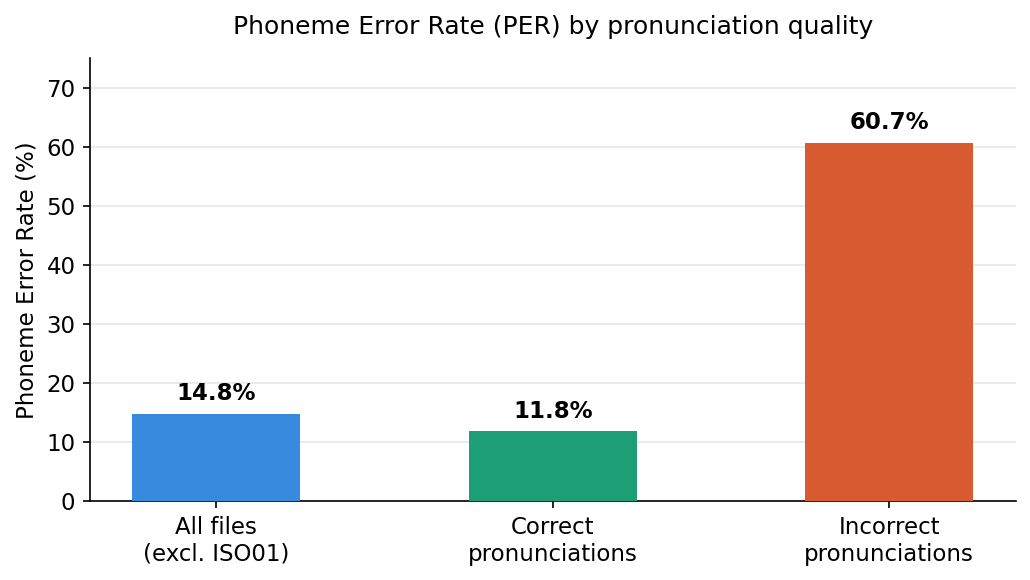

Plot 1 saved.


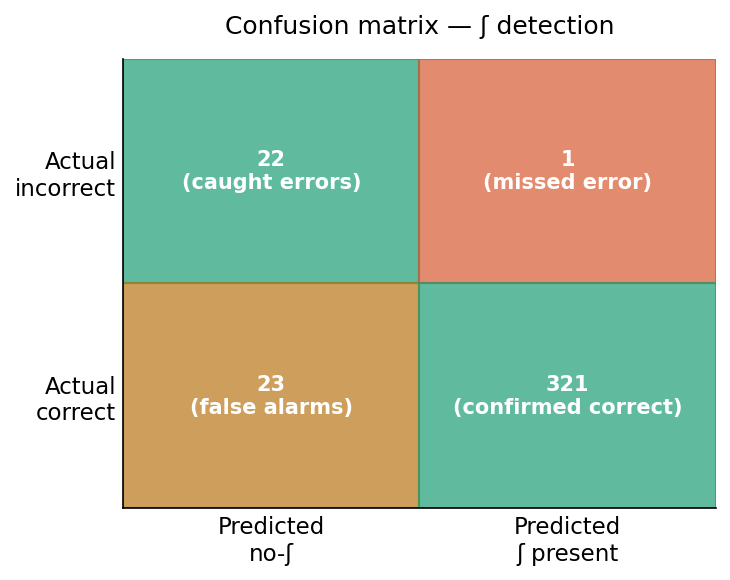

Plot 2 saved.


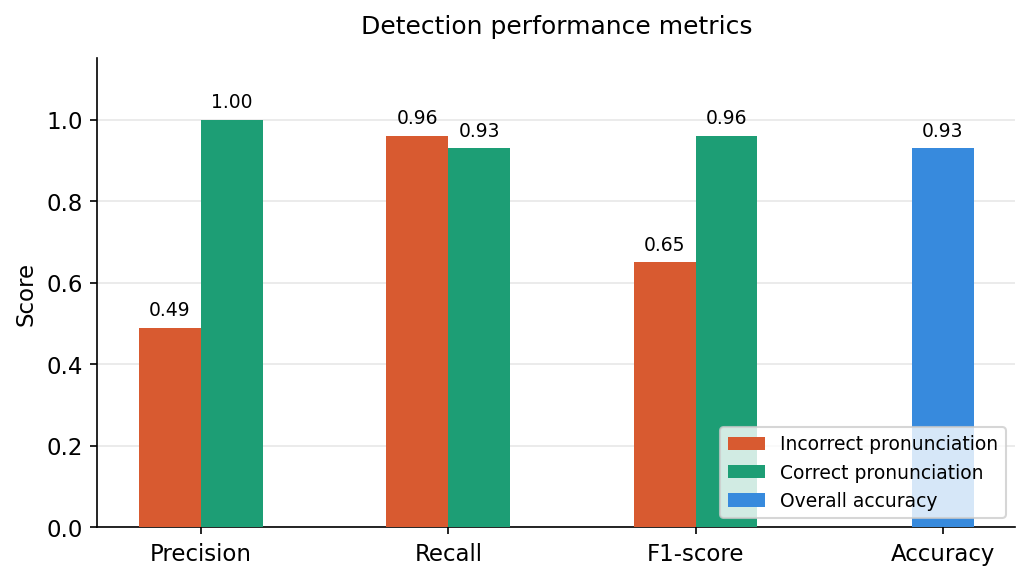

Plot 3 saved.


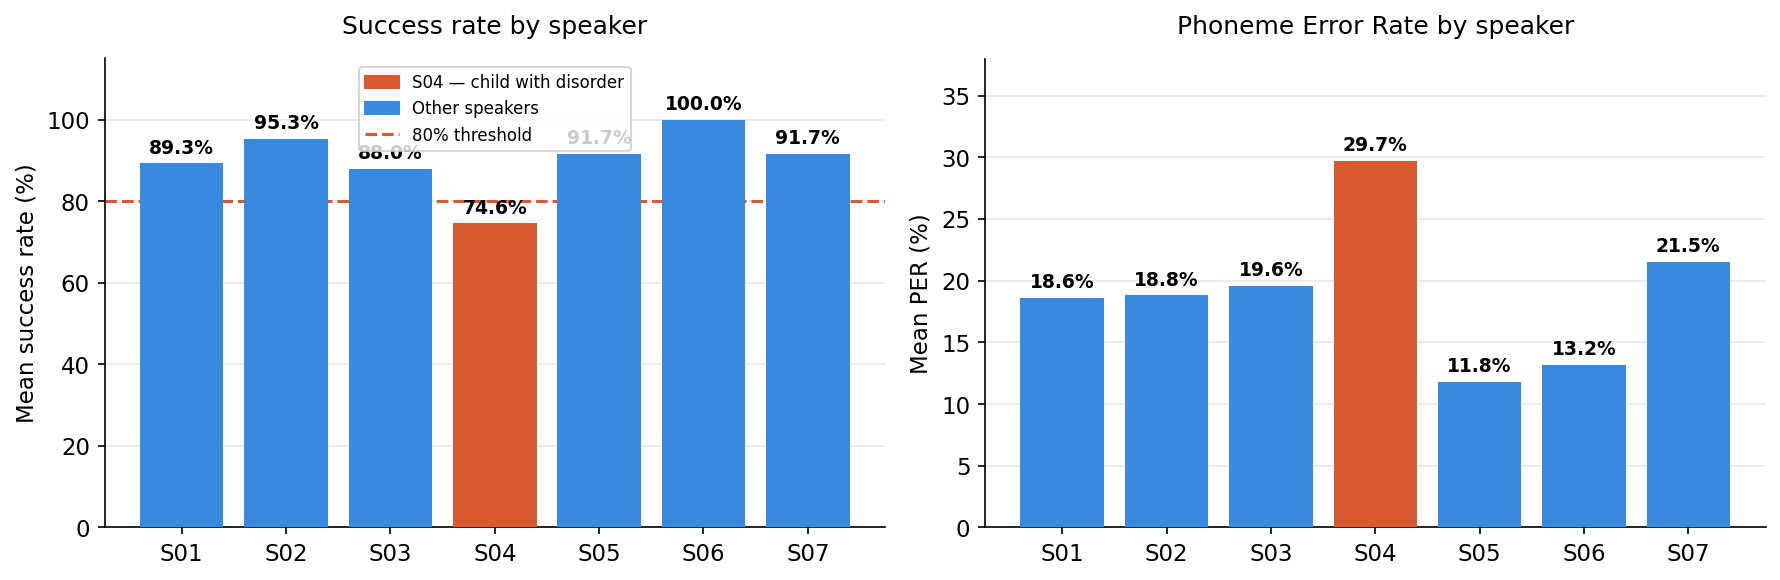

Plot 4 saved.


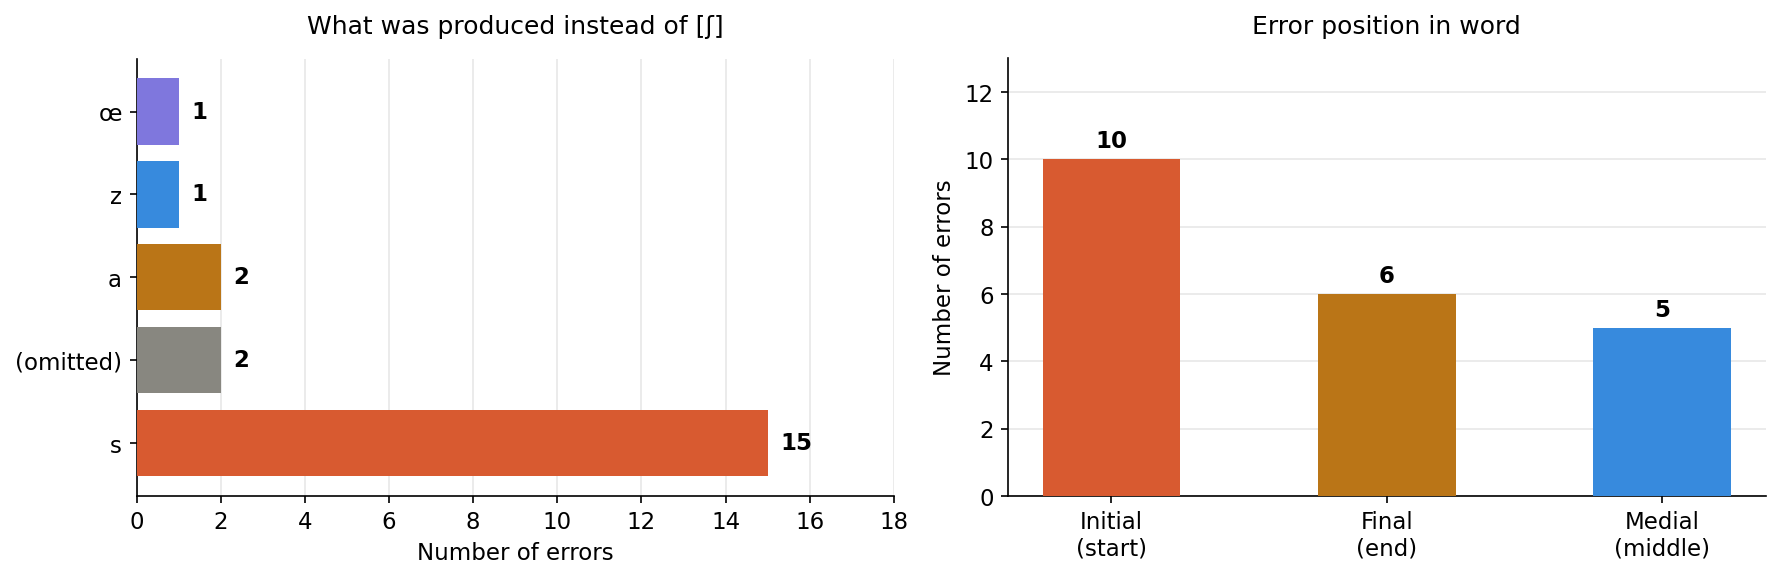

Plot 5 saved.


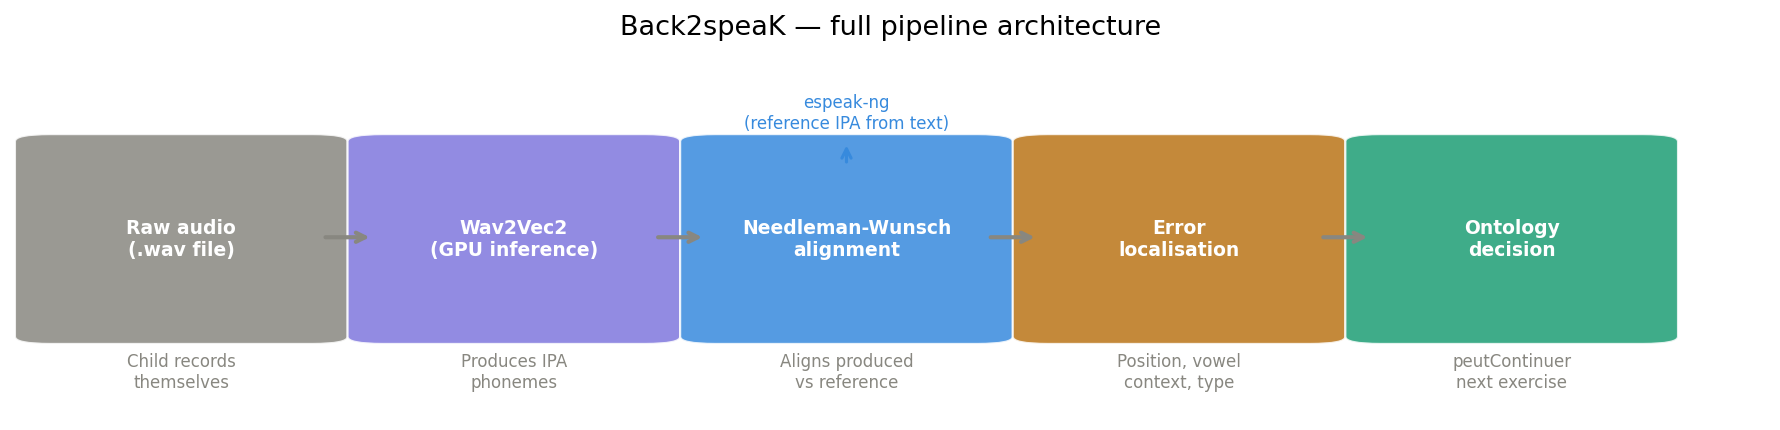

Plot 6 saved.

All 6 plots saved to: C:\Users\Sarah\back2speak\graphs


In [40]:
# Cell 11 — Visualization of results for presentation
# Generates 6 plots covering all the metrics we computed

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Style
plt.rcParams["font.family"]  = "DejaVu Sans"
plt.rcParams["font.size"]    = 11
plt.rcParams["figure.dpi"]   = 150
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

OUTPUT_GRAPHS = r"C:\Users\Sarah\back2speak\graphs"
os.makedirs(OUTPUT_GRAPHS, exist_ok=True)

# ── Colors ────────────────────────────────────────────────────
C_BLUE   = "#378ADD"
C_TEAL   = "#1D9E75"
C_CORAL  = "#D85A30"
C_GRAY   = "#888780"
C_AMBER  = "#BA7517"
C_PURPLE = "#7F77DD"

# ============================================================
# PLOT 1 — PER by label (correct vs incorrect)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))

categories = ["All files\n(excl. ISO01)", "Correct\npronunciations", "Incorrect\npronunciations"]
values     = [14.8, 11.8, 60.7]
colors     = [C_BLUE, C_TEAL, C_CORAL]

bars = ax.bar(categories, values, color=colors, width=0.5, zorder=3)
ax.set_ylabel("Phoneme Error Rate (%)")
ax.set_title("Phoneme Error Rate (PER) by pronunciation quality", fontsize=12, pad=12)
ax.set_ylim(0, 75)
ax.yaxis.grid(True, alpha=0.3, zorder=0)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val}%", ha="center", va="bottom", fontweight="bold")

ax.axhline(y=80, color=C_CORAL, linestyle="--", alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot1_per_by_label.png"), bbox_inches="tight")
plt.show()
print("Plot 1 saved.")

# ============================================================
# PLOT 2 — Confusion matrix heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))

cm_data = np.array([[22, 1], [23, 321]])
labels  = [["22\n(caught errors)", "1\n(missed error)"],
           ["23\n(false alarms)",  "321\n(confirmed correct)"]]
colors_cm = [[C_TEAL, C_CORAL], [C_AMBER, C_TEAL]]

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                     color=colors_cm[i][j], alpha=0.7))
        ax.text(j+0.5, 1.5-i, labels[i][j],
                ha="center", va="center", fontsize=10, fontweight="bold",
                color="white")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Predicted\nno-ʃ", "Predicted\nʃ present"])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["Actual\ncorrect", "Actual\nincorrect"])
ax.set_title("Confusion matrix — ʃ detection", fontsize=12, pad=12)
ax.tick_params(length=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot2_confusion_matrix.png"), bbox_inches="tight")
plt.show()
print("Plot 2 saved.")

# ============================================================
# PLOT 3 — Precision, Recall, F1 bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))

metrics       = ["Precision", "Recall", "F1-score", "Accuracy"]
incorrect_vals = [0.49, 0.96, 0.65, None]
correct_vals   = [1.00, 0.93, 0.96, None]
overall_vals   = [None, None, None, 0.93]

x = np.arange(len(metrics))
w = 0.25

bars1 = ax.bar(x[:3] - w/2, [0.49, 0.96, 0.65], w, label="Incorrect pronunciation", color=C_CORAL, zorder=3)
bars2 = ax.bar(x[:3] + w/2, [1.00, 0.93, 0.96], w, label="Correct pronunciation",   color=C_TEAL,  zorder=3)
bars3 = ax.bar([3],          [0.93],              w, label="Overall accuracy",        color=C_BLUE,  zorder=3)

ax.set_ylabel("Score")
ax.set_title("Detection performance metrics", fontsize=12, pad=12)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.legend(fontsize=9)

for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot3_metrics.png"), bbox_inches="tight")
plt.show()
print("Plot 3 saved.")

# ============================================================
# PLOT 4 — Success rate and PER by speaker
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

speakers      = ["S01", "S02", "S03", "S04", "S05", "S06", "S07"]
success_rates = [89.3, 95.3, 88.0, 74.6, 91.7, 100.0, 91.7]
per_values    = [18.6, 18.8, 19.6, 29.7, 11.8, 13.2, 21.5]
bar_colors    = [C_CORAL if s == "S04" else C_BLUE for s in speakers]

# Success rate
bars = ax1.bar(speakers, success_rates, color=bar_colors, zorder=3)
ax1.axhline(y=80, color=C_CORAL, linestyle="--", linewidth=1.5, label="80% threshold")
ax1.set_ylabel("Mean success rate (%)")
ax1.set_title("Success rate by speaker", fontsize=12, pad=12)
ax1.set_ylim(0, 115)
ax1.yaxis.grid(True, alpha=0.3, zorder=0)
ax1.legend(fontsize=9)

for bar, val in zip(bars, success_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{val}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# PER
bars2 = ax2.bar(speakers, per_values, color=bar_colors, zorder=3)
ax2.set_ylabel("Mean PER (%)")
ax2.set_title("Phoneme Error Rate by speaker", fontsize=12, pad=12)
ax2.set_ylim(0, 38)
ax2.yaxis.grid(True, alpha=0.3, zorder=0)

for bar, val in zip(bars2, per_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color=C_CORAL, label="S04 — child with disorder"),
    mpatches.Patch(color=C_BLUE,  label="Other speakers"),
]
ax1.legend(handles=legend_patches + [plt.Line2D([0], [0], color=C_CORAL,
           linestyle="--", label="80% threshold")], fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot4_by_speaker.png"), bbox_inches="tight")
plt.show()
print("Plot 4 saved.")

# ============================================================
# PLOT 5 — Substitution analysis: what replaces ʃ
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# What was produced instead of ʃ
phonemes = ["s", "(omitted)", "a", "z", "œ"]
counts   = [15, 2, 2, 1, 1]
colors_p = [C_CORAL, C_GRAY, C_AMBER, C_BLUE, C_PURPLE]

bars = ax1.barh(phonemes, counts, color=colors_p, zorder=3)
ax1.set_xlabel("Number of errors")
ax1.set_title("What was produced instead of [ʃ]", fontsize=12, pad=12)
ax1.xaxis.grid(True, alpha=0.3, zorder=0)
ax1.set_xlim(0, 18)

for bar, val in zip(bars, counts):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontweight="bold")

# By position in word
positions  = ["Initial\n(start)", "Final\n(end)", "Medial\n(middle)"]
pos_counts = [10, 6, 5]
pos_colors = [C_CORAL, C_AMBER, C_BLUE]

bars2 = ax2.bar(positions, pos_counts, color=pos_colors, width=0.5, zorder=3)
ax2.set_ylabel("Number of errors")
ax2.set_title("Error position in word", fontsize=12, pad=12)
ax2.set_ylim(0, 13)
ax2.yaxis.grid(True, alpha=0.3, zorder=0)

for bar, val in zip(bars2, pos_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot5_substitution.png"), bbox_inches="tight")
plt.show()
print("Plot 5 saved.")

# ============================================================
# PLOT 6 — Pipeline architecture summary
# ============================================================
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

steps = [
    ("Raw audio\n(.wav file)", C_GRAY),
    ("Wav2Vec2\n(GPU inference)", C_PURPLE),
    ("Needleman-Wunsch\nalignment", C_BLUE),
    ("Error\nlocalisation", C_AMBER),
    ("Ontology\ndecision", C_TEAL),
]

box_w, box_h = 0.15, 0.55
gap          = 0.04
start_x      = 0.02

for i, (label, color) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch(
        (x, 0.22), box_w, box_h,
        boxstyle="round,pad=0.02",
        facecolor=color, edgecolor="white",
        alpha=0.85, transform=ax.transAxes
    )
    ax.add_patch(rect)
    ax.text(x + box_w/2, 0.22 + box_h/2, label,
            ha="center", va="center", fontsize=9,
            color="white", fontweight="bold",
            transform=ax.transAxes)

    if i < len(steps) - 1:
        ax.annotate("", 
                    xy=(x + box_w + gap - 0.005, 0.5),
                    xytext=(x + box_w + 0.005, 0.5),
                    xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color=C_GRAY, lw=2))

# Labels below each box
sub_labels = [
    "Child records\nthemselves",
    "Produces IPA\nphonemes",
    "Aligns produced\nvs reference",
    "Position, vowel\ncontext, type",
    "peutContinuer\nnext exercise",
]
for i, label in enumerate(sub_labels):
    x = start_x + i * (box_w + gap)
    ax.text(x + box_w/2, 0.12, label,
            ha="center", va="center", fontsize=8,
            color=C_GRAY, transform=ax.transAxes)

# espeak label above alignment
ax.text(start_x + 2*(box_w+gap) + box_w/2, 0.85,
        "espeak-ng\n(reference IPA from text)",
        ha="center", va="center", fontsize=8,
        color=C_BLUE, transform=ax.transAxes)
ax.annotate("",
            xy=(start_x + 2*(box_w+gap) + box_w/2, 0.77),
            xytext=(start_x + 2*(box_w+gap) + box_w/2, 0.7),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color=C_BLUE, lw=1.5))

ax.set_title("Back2speaK — full pipeline architecture", fontsize=13, pad=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_GRAPHS, "plot6_pipeline.png"), bbox_inches="tight")
plt.show()
print("Plot 6 saved.")

print()
print(f"All 6 plots saved to: {OUTPUT_GRAPHS}")